<a href="https://colab.research.google.com/github/Yasinnn7/CODSOFT-ML/blob/main/Bank_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df=pd.read_csv('/content/Churn_Modelling.csv', header=0)

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.size

140000

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df.isnull().values.any()

np.False_

In [10]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
df.index

RangeIndex(start=0, stop=10000, step=1)

In [12]:
print(df['Geography'].unique())
print(df['Gender'].unique())
print(df['NumOfProducts'].unique())
print(df['HasCrCard'].unique())
print(df['IsActiveMember'].unique())
print(df['Exited'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']
[1 3 2 4]
[1 0]
[1 0]
[1 0]


In [13]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [14]:
df.axes

[RangeIndex(start=0, stop=10000, step=1),
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
        'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
        'IsActiveMember', 'EstimatedSalary', 'Exited'],
       dtype='object')]

In [15]:
df.iloc[0:4]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [16]:
df.loc[:, 'CustomerId']

,CustomerId
0,15634602
1,15647311
2,15619304
3,15701354
4,15737888
...,...
9995,15606229
9996,15569892
9997,15584532
9998,15682355


# Data vislization


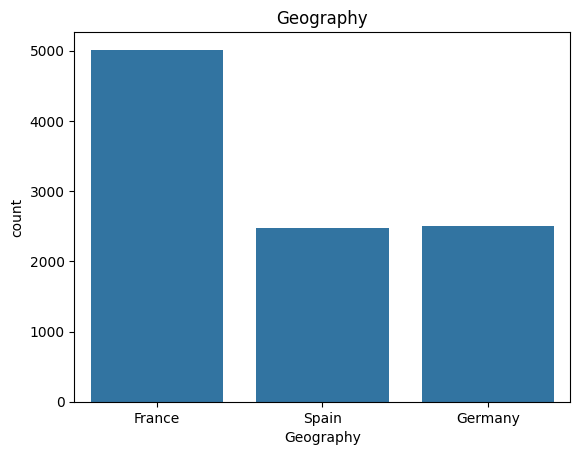

In [17]:
sns.countplot(x='Geography', data=df)
plt.title('Geography')
plt.show()

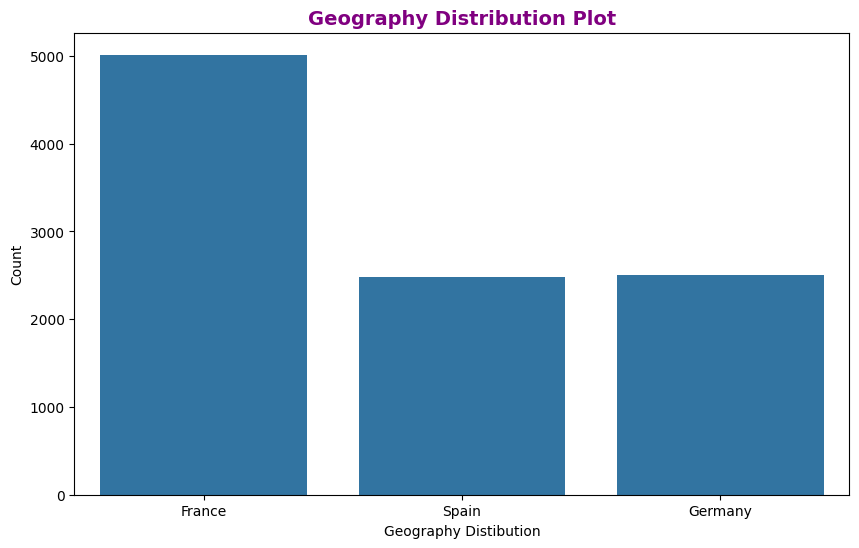

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='Geography', data=df)
plt.ylabel('Count')
plt.xlabel('Geography Distibution')
plt.title('Geography Distribution Plot', fontsize=14, fontweight='bold', color='purple')
plt.show()

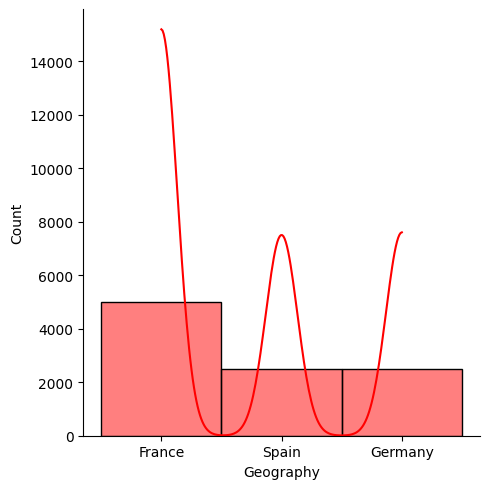

In [19]:
sns.displot(df.Geography, kde=True, color='red')
plt.show()

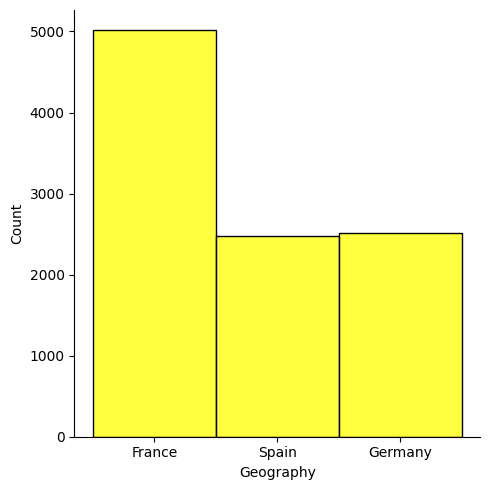

In [20]:
sns.displot(df.Geography, color='yellow')

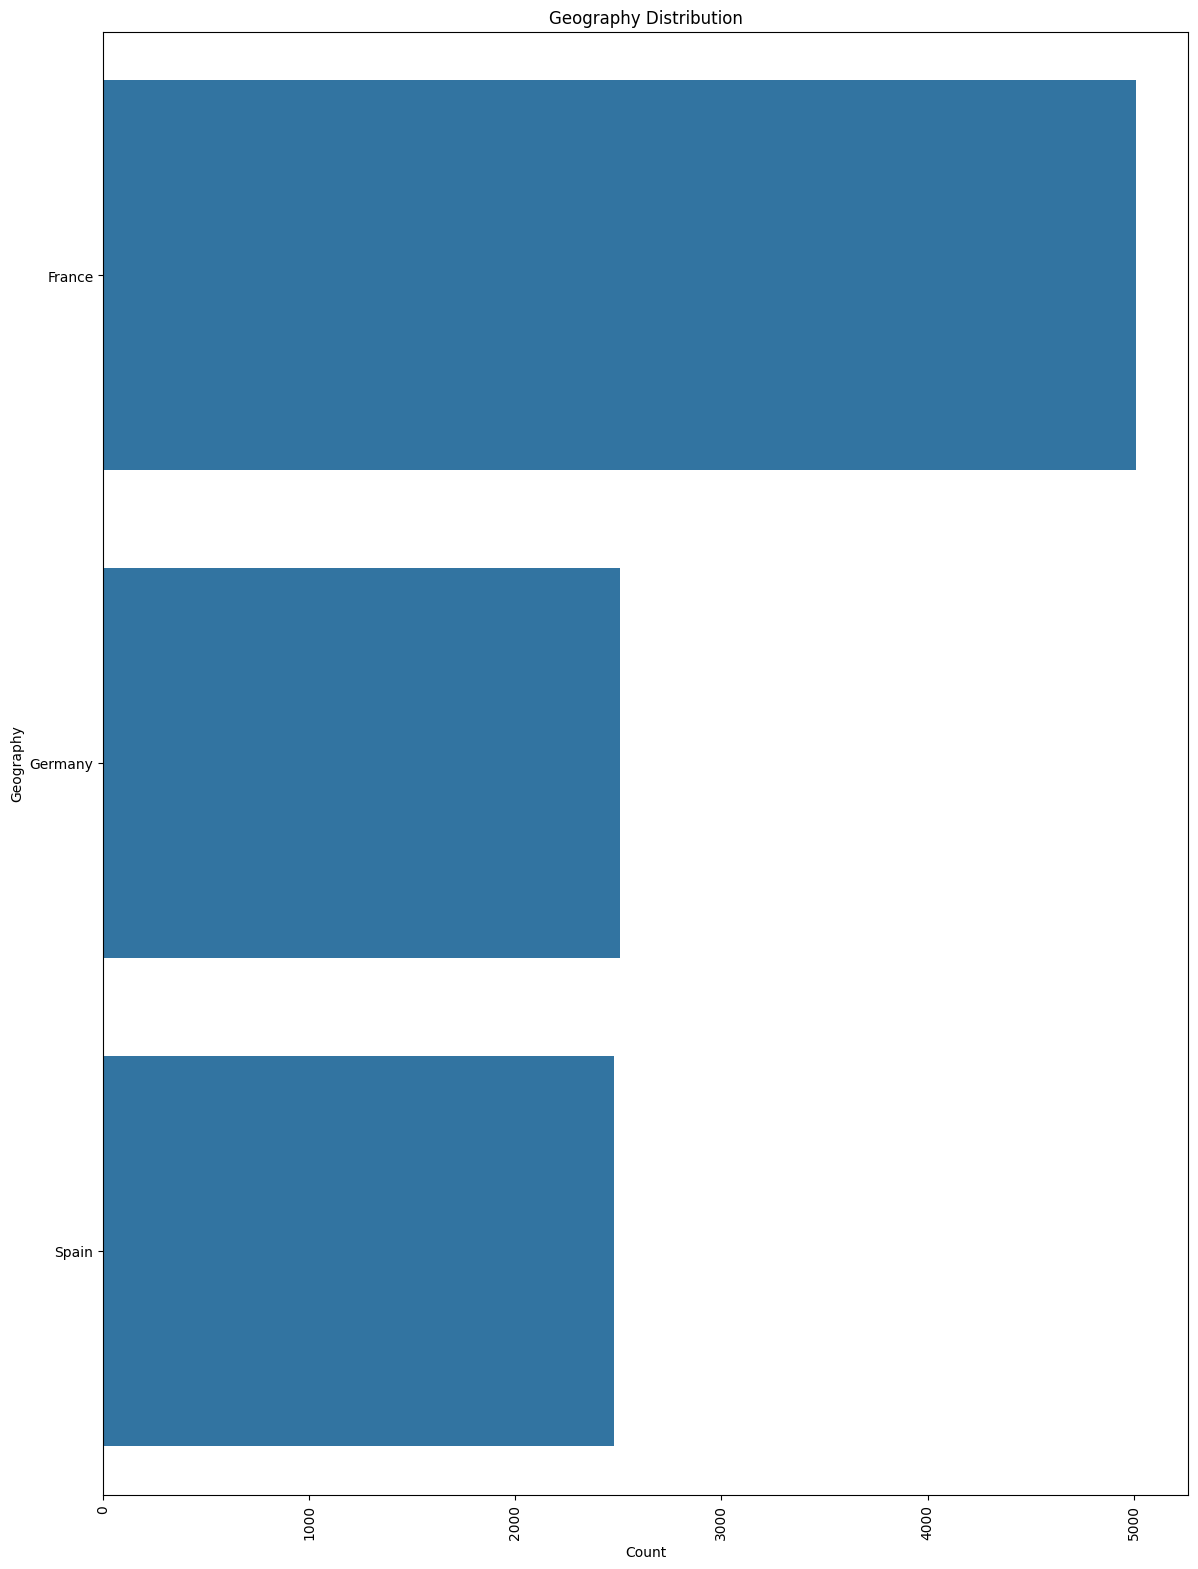

In [21]:
plt.figure(figsize=(14,19))
count1=df.Geography.value_counts()
sns.barplot(x=count1 , y=count1.index, orient='h')
plt.xlabel('Count')
plt.ylabel('Geography')
plt.title('Geography Distribution')
plt.xticks(rotation=90)
plt.show()

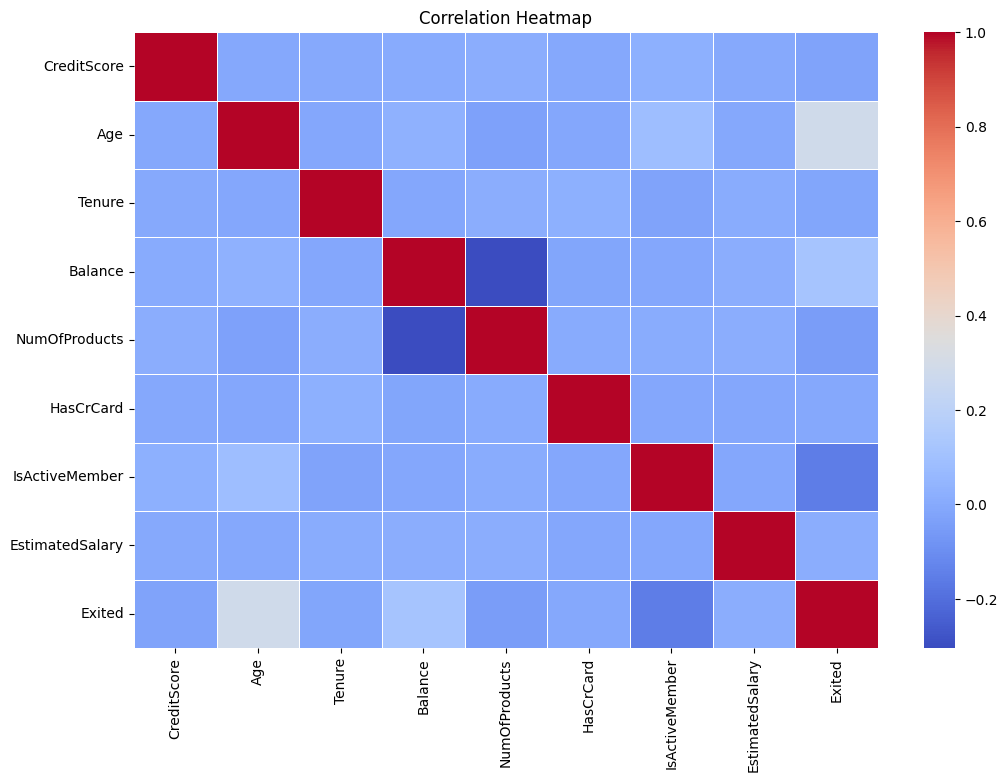

In [22]:
df_numeric = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'])
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,annot=False, cmap='coolwarm', linewidths=0.5,fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [23]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [24]:
df=pd.get_dummies(df, drop_first=True)

In [25]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [26]:
x=df.drop('Exited', axis=1)
y=df['Exited']

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# Logistic Regression

In [29]:
lr_model=LogisticRegression()

In [30]:
lr_model.fit(x_train_scaled, y_train)

LogisticRegression()

In [31]:
lr_prediction=lr_model.predict(x_test_scaled)

In [32]:
print("Logistic Regreession Model: ")
print(confusion_matrix(y_test, lr_prediction))
print(classification_report(y_test, lr_prediction))
print(accuracy_score(y_test, lr_prediction))
print(precision_score(y_test, lr_prediction))
print(recall_score(y_test, lr_prediction))
print(f1_score(y_test, lr_prediction))

Logistic Regreession Model: 
[[1543   64]
 [ 314   79]]
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

0.811
0.5524475524475524
0.2010178117048346
0.2947761194029851


# Random Forest Classification

In [33]:
rf_model=RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

In [34]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=42)

In [35]:
rf_prediction=rf_model.predict(x_test)

In [36]:
print("Random Forest Model: ")
print(confusion_matrix(y_test, rf_prediction))
print(classification_report(y_test, rf_prediction))
print(accuracy_score(y_test, rf_prediction))
print(precision_score(y_test, rf_prediction))
print(recall_score(y_test, rf_prediction))
print(f1_score(y_test, rf_prediction))


Random Forest Model: 
[[1546   61]
 [ 209  184]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000

0.865
0.7510204081632653
0.4681933842239186
0.5768025078369906


# Train Gradient Boosting Model

In [37]:
gb_model=GradientBoostingClassifier(n_estimators=1000, learning_rate=0.02,max_depth=1,random_state=42)

In [38]:
gb_model.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.02, max_depth=1, n_estimators=1000,
                           random_state=42)

In [39]:
print("Gradient Boosting Model: ")
gb_prediction=gb_model.predict(x_test)
print(confusion_matrix(y_test, gb_prediction))
print(classification_report(y_test, gb_prediction))
print(accuracy_score(y_test, gb_prediction))
print(precision_score(y_test, gb_prediction))
print(recall_score(y_test, gb_prediction))
print(f1_score(y_test, gb_prediction))

Gradient Boosting Model: 
[[1550   57]
 [ 224  169]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1607
           1       0.75      0.43      0.55       393

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000

0.8595
0.7477876106194691
0.4300254452926209
0.5460420032310178
